Name: Lin Qizhou

Key insights / takeaways:
- I trained a GAN on floorplan images using an adversarial setup with a DCGAN-style Generator and Discriminator.
- I stabilized training with standard techniques such as normalization to [-1, 1], Adam optimizers, and careful update scheduling between G and D.
- I generated new synthetic floorplans by sampling latent noise vectors and saving image grids for qualitative inspection, and I saved model checkpoints for reproducibility.

In [1]:
!pip -q install -U torch torchvision pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 48.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


In [3]:
from google.colab import files
uploaded = files.upload()
print(list(uploaded.keys()))

Saving floorplans_v2-20251223T170650Z-3-001.zip to floorplans_v2-20251223T170650Z-3-001.zip
['floorplans_v2-20251223T170650Z-3-001.zip']


In [4]:
from pathlib import Path

root = Path("/content")
zips = sorted(root.glob("*.zip"))
print([p.name for p in zips])

cands = [p for p in zips if "floorplans" in p.name.lower()]
print(str(cands[0]) if cands else "not_found")

['floorplans_v2-20251223T170650Z-3-001.zip']
/content/floorplans_v2-20251223T170650Z-3-001.zip


In [5]:
!pip -q install -U --force-reinstall "Pillow>=10.4.0"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


In [6]:
from pathlib import Path
import zipfile

zip_path = Path("/content/floorplans_v2-20251223T170650Z-3-001.zip")
if not zip_path.exists():
    raise FileNotFoundError(str(zip_path))

workdir = Path("/content/work_floorplans_gan")
workdir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(workdir)

img_exts = {".png", ".jpg", ".jpeg", ".webp"}
img_files = [p for p in workdir.rglob("*") if p.suffix.lower() in img_exts]
if not img_files:
    raise RuntimeError("no images found")

print(str(workdir))
print(len(img_files))
print(str(img_files[0]))

/content/work_floorplans_gan
1000
/content/work_floorplans_gan/floorplans_v2/floorplan_00692.jpg


In [7]:
!pip -q install -U --force-reinstall "Pillow==11.1.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 41.7 MB/s eta 0:00:00


In [8]:
import PIL
print(PIL.__version__)

11.3.0


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(str(device))

workdir = Path("/content/work_floorplans_gan")
img_exts = {".png", ".jpg", ".jpeg", ".webp"}
img_paths = sorted([p for p in workdir.rglob("*") if p.suffix.lower() in img_exts])
if not img_paths:
    raise RuntimeError("no images found")

size = 128
batch_size = 64
num_workers = 0

transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

class FloorplanDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)

ds = FloorplanDataset(img_paths, transform)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)

x = next(iter(dl))
print(len(ds))
print(tuple(x.shape))
print(float(x.min()), float(x.max()))

cpu
1000
(64, 3, 128, 128)
-1.0 1.0


In [10]:
import torch
import torch.nn as nn

nz = 128
ngf = 64
ndf = 64
nc = 3

class Generator(nn.Module):
    def __init__(self, nz=128, ngf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)

def weights_init(m):
    name = m.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    if "BatchNorm" in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = Generator(nz=nz, ngf=ngf, nc=nc).to(device)
D = Discriminator(ndf=ndf, nc=nc).to(device)

G.apply(weights_init)
D.apply(weights_init)

print(sum(p.numel() for p in G.parameters()))
print(sum(p.numel() for p in D.parameters()))

13245312
11164416


In [11]:
import torch
import torch.nn as nn
from torchvision.utils import make_grid, save_image
from pathlib import Path
from tqdm import tqdm

outdir = Path("/content/gan_floorplan_outputs")
outdir.mkdir(parents=True, exist_ok=True)

criterion = nn.BCEWithLogitsLoss()

lr = 2e-4
beta1 = 0.5
beta2 = 0.999
epochs = 3

optD = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))
optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))

fixed_z = torch.randn(16, nz, 1, 1, device=device)

def save_samples(step_tag):
    with torch.no_grad():
        fake = G(fixed_z).detach()
        vis = (fake.clamp(-1, 1) + 1) / 2.0
        grid = make_grid(vis, nrow=4)
        path = outdir / f"samples_{step_tag}.png"
        save_image(grid, path)
        return str(path)

global_step = 0
save_samples("init")

for ep in range(epochs):
    pbar = tqdm(dl, total=len(dl))
    for real in pbar:
        real = real.to(device)
        b = real.size(0)

        D.zero_grad(set_to_none=True)
        label_real = torch.ones(b, device=device)
        out_real = D(real)
        lossD_real = criterion(out_real, label_real)

        z = torch.randn(b, nz, 1, 1, device=device)
        fake = G(z).detach()
        label_fake = torch.zeros(b, device=device)
        out_fake = D(fake)
        lossD_fake = criterion(out_fake, label_fake)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optD.step()

        G.zero_grad(set_to_none=True)
        z = torch.randn(b, nz, 1, 1, device=device)
        fake = G(z)
        label_gen = torch.ones(b, device=device)
        out_gen = D(fake)
        lossG = criterion(out_gen, label_gen)
        lossG.backward()
        optG.step()

        global_step += 1
        if global_step % 200 == 0:
            saved_path = save_samples(f"ep{ep+1}_step{global_step}")
        else:
            saved_path = None

        pbar.set_description(f"ep={ep+1}/{epochs} d={lossD.item():.4f} g={lossG.item():.4f}")

final_path = save_samples("final")
print(final_path)

ep=3/3 d=2.9827 g=32.3840: 100%|██████████| 15/15 [06:16<00:00, 25.08s/it]


/content/gan_floorplan_outputs/samples_final.png


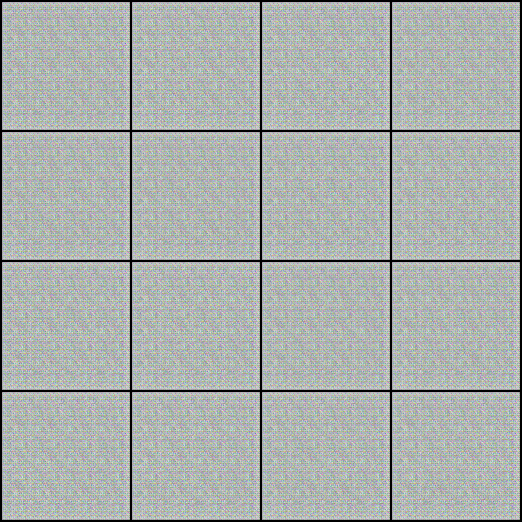

/content/gan_floorplan_outputs/samples_final.png


In [12]:
from PIL import Image
from IPython.display import display
from pathlib import Path

p = Path("/content/gan_floorplan_outputs/samples_final.png")
if not p.exists():
    cands = sorted(Path("/content/gan_floorplan_outputs").glob("samples_*.png"))
    if not cands:
        raise FileNotFoundError("no sample images found")
    p = cands[-1]

display(Image.open(str(p)))
print(str(p))

In [13]:
import torch
from pathlib import Path

ckpt_dir = Path("/content/gan_floorplan_checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)

ckpt_path = ckpt_dir / "dcgan_floorplans.pth"
torch.save(
    {
        "G_state_dict": G.state_dict(),
        "D_state_dict": D.state_dict(),
        "nz": nz,
        "ngf": ngf,
        "ndf": ndf,
        "nc": nc,
        "image_size": 128,
    },
    ckpt_path,
)

print(str(ckpt_path))

/content/gan_floorplan_checkpoints/dcgan_floorplans.pth


In [14]:
import torch
from torchvision.utils import make_grid, save_image
from pathlib import Path

@torch.no_grad()
def gan_generate(G, outdir, n_samples=16, nz=128, size=128, seed=0, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    z = torch.randn(n_samples, nz, 1, 1, device=device, generator=g)
    fake = G(z)
    vis = (fake.clamp(-1, 1) + 1) / 2.0
    grid = make_grid(vis, nrow=int(n_samples ** 0.5))

    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    out_path = outdir / f"gan_samples_n{n_samples}_seed{seed}.png"
    save_image(grid, out_path)
    return str(out_path)

new_path = gan_generate(G, outdir="/content/gan_floorplan_outputs", n_samples=16, nz=nz, seed=123, device=device)
print(new_path)

/content/gan_floorplan_outputs/gan_samples_n16_seed123.png


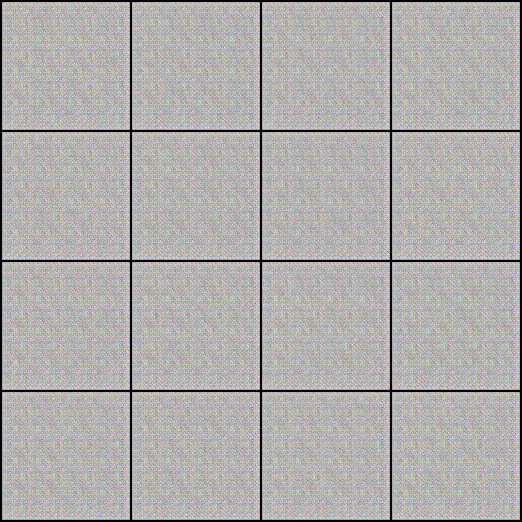

In [15]:
from PIL import Image
from IPython.display import display

display(Image.open(new_path))